In [4]:
from google.colab import files
uploaded = files.upload()


Saving social_media_user_behavior.csv to social_media_user_behavior.csv


In [ ]:
# Cell 1: Ingesting Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Model selection and normalization tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, mean_absolute_error,
                             mean_squared_error, r2_score, roc_curve)

# Classification Suite (10 Models)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Regression Suite (10 Models)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

print(" [STATUS] System environments and training packages initialized.")

 [STATUS] System environments and training packages initialized.


In [6]:
# Cell 2: Loading and Processing Dataset Space
csv_filename = 'social_media_user_behavior.csv'

if not os.path.exists(csv_filename):
    raise FileNotFoundError(f"Ensure '{csv_filename}' is uploaded directly to your Colab workspace root directory.")

# Load raw attributes
df = pd.read_csv(csv_filename)
print(f" -> Initial shape loaded: {df.shape}")

# Drop operational indices to prevent artificial tracking biases
df = df.drop(columns=['user_id', 'account_join_date'], errors='ignore')

# Deduplicate identical value streams
df.drop_duplicates(inplace=True)

# Standard Data Imputation Rule matching deployment configurations
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Statistical Feature Construction (Phase 4)
df['engagement_density_ratio'] = df['likes_given_per_day'] / (df['posts_per_week'] + 1)
df['session_intensity'] = df['avg_session_duration_min'] * df['sessions_per_day']

print(f" -> Processing completed. New dataset matrix shape: {df.shape}")

 -> Initial shape loaded: (2000, 34)
 -> Processing completed. New dataset matrix shape: (2000, 34)


In [7]:
# Cell 3: Feature Matrix Selection Strategy (Classification)
class_target = 'screen_time_concern'
reg_target = 'daily_usage_hours'

# Drop alternative continuous outcome vectors to ensure cross-leak isolation
X_c = df.drop(columns=[class_target, reg_target], errors='ignore')
y_c = df[class_target]

# Create dynamic label encoding tracking arrays
class_labels_blueprint = sorted(y_c.unique().tolist())
class_encoder_lookup = {label: i for i, label in enumerate(class_labels_blueprint)}
y_c_encoded = y_c.map(class_encoder_lookup).values

# Generate multi-dimensional dummies matching drop_first rules
categorical_features_c = X_c.select_dtypes(include=['object']).columns.tolist()
X_c_encoded = pd.get_dummies(X_c, columns=categorical_features_c, drop_first=True)

# Extract top features via Pearson absolute correlation matrices
temp_c_matrix = X_c_encoded.copy()
temp_c_matrix['__target__'] = y_c_encoded
top_classification_features = temp_c_matrix.corr()['__target__'].abs().drop('__target__').sort_values(ascending=False).head(15).index.tolist()

print(" -> Top 15 Highly Correlated Features chosen for Pipeline A:")
for idx, feature in enumerate(top_classification_features, 1):
    print(f"    {idx}. {feature}")

 -> Top 15 Highly Correlated Features chosen for Pipeline A:
    1. primary_platform_LinkedIn
    2. takes_social_media_breaks_Occasionally
    3. country_Nigeria
    4. profession_Student
    5. country_UK
    6. profession_Marketer
    7. dms_sent_per_day
    8. preferred_content_type_Reels/Shorts
    9. takes_social_media_breaks_Yes
    10. mood_while_scrolling_Happy
    11. sleep_disruption_Severe impact
    12. country_UAE
    13. country_India
    14. preferred_content_type_Entertainment
    15. shares_per_day


In [8]:
# Cell 4: Splitting, Scaling, Training, and Evaluating Classification Suite
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c_encoded[top_classification_features], y_c_encoded, test_size=0.20, random_state=42)

scaler_classification = StandardScaler()
X_train_c_scaled = scaler_classification.fit_transform(X_train_c)
X_test_c_scaled = scaler_classification.transform(X_test_c)

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "ANN (MLP)": MLPClassifier(max_iter=500, random_state=42)
}

classification_scores = {}
best_class_acc = -1
best_class_model_name = None
best_class_model_obj = None

print(f"{'Algorithm Model':<25} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 75)

for name, model in classification_models.items():
    model.fit(X_train_c_scaled, y_train_c)
    preds = model.predict(X_test_c_scaled)

    acc = accuracy_score(y_test_c, preds)
    prec = precision_score(y_test_c, preds, average='weighted')
    rec = recall_score(y_test_c, preds, average='weighted')
    f1 = f1_score(y_test_c, preds, average='weighted')

    classification_scores[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    print(f"{name:<25} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f}")

    if acc > best_class_acc:
        best_class_acc = acc
        best_class_model_name = name
        best_class_model_obj = model

print(f"\n [WINNING DESIGN] Best Classification Engine: {best_class_model_name} with Accuracy: {best_class_acc:.4f}")

Algorithm Model           | Accuracy   | Precision  | Recall     | F1-Score  
---------------------------------------------------------------------------
Logistic Regression       | 0.3950     | 0.3793     | 0.3950     | 0.3578    
Decision Tree             | 0.3650     | 0.3697     | 0.3650     | 0.3650    
Random Forest             | 0.3450     | 0.3380     | 0.3450     | 0.3380    
SVM                       | 0.3850     | 0.3176     | 0.3850     | 0.3389    
KNN                       | 0.3550     | 0.3578     | 0.3550     | 0.3461    
Naive Bayes               | 0.3975     | 0.3734     | 0.3975     | 0.3762    
AdaBoost                  | 0.4050     | 0.3585     | 0.4050     | 0.3479    
Gradient Boosting         | 0.3975     | 0.3961     | 0.3975     | 0.3750    
XGBoost                   | 0.3925     | 0.3879     | 0.3925     | 0.3839    
ANN (MLP)                 | 0.3825     | 0.3520     | 0.3825     | 0.3614    

 [WINNING DESIGN] Best Classification Engine: AdaBoost with Accur

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [9]:
# Cell 5: Feature Matrix Selection Strategy (Regression)
X_r = df.drop(columns=[reg_target, class_target], errors='ignore')
y_r = df[reg_target].values

categorical_features_r = X_r.select_dtypes(include=['object']).columns.tolist()
X_r_encoded = pd.get_dummies(X_r, columns=categorical_features_r, drop_first=True)

temp_r_matrix = X_r_encoded.copy()
temp_r_matrix['__target__'] = y_r
top_regression_features = temp_r_matrix.corr()['__target__'].abs().drop('__target__').sort_values(ascending=False).head(15).index.tolist()

print(" -> Top 15 Highly Correlated Features chosen for Pipeline B:")
for idx, feature in enumerate(top_regression_features, 1):
    print(f"    {idx}. {feature}")

 -> Top 15 Highly Correlated Features chosen for Pipeline B:
    1. session_intensity
    2. avg_session_duration_min
    3. takes_social_media_breaks_Occasionally
    4. profession_Teacher
    5. preferred_device_Laptop
    6. profession_Researcher
    7. comments_per_day
    8. preferred_device_Smartphone
    9. sleep_disruption_No impact
    10. notification_frequency_Do Not Disturb
    11. following_count
    12. primary_platform_Twitter/X
    13. takes_social_media_breaks_Yes
    14. country_USA
    15. primary_platform_TikTok


In [10]:
# Cell 6: Splitting, Scaling, Training, and Evaluating Regression Suite
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r_encoded[top_regression_features], y_r, test_size=0.20, random_state=42)

scaler_regression = StandardScaler()
X_train_r_scaled = scaler_regression.fit_transform(X_train_r)
X_test_r_scaled = scaler_regression.transform(X_test_r)

regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "Extra Trees Regressor": ExtraTreesRegressor(random_state=42),
    "ANN Regressor (MLP)": MLPRegressor(max_iter=500, random_state=42)
}

regression_scores = {}
best_reg_r2 = -float('inf')
best_reg_model_name = None
best_reg_model_obj = None

print(f"{'Algorithm Model':<28} | {'MAE':<8} | {'MSE':<8} | {'RMSE':<8} | {'R2 Score':<8}")
print("-" * 75)

for name, model in regression_models.items():
    model.fit(X_train_r_scaled, y_train_r)
    preds = model.predict(X_test_r_scaled)

    mae = mean_absolute_error(y_test_r, preds)
    mse = mean_squared_error(y_test_r, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_r, preds)

    regression_scores[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    print(f"{name:<28} | {mae:<8.3f} | {mse:<8.3f} | {rmse:<8.3f} | {r2:<8.3f}")

    if r2 > best_reg_r2:
        best_reg_r2 = r2
        best_reg_model_name = name
        best_reg_model_obj = model

print(f"\n [WINNING DESIGN] Best Regression Engine: {best_reg_model_name} with R² Score: {best_reg_r2:.4f}")

Algorithm Model              | MAE      | MSE      | RMSE     | R2 Score
---------------------------------------------------------------------------
Linear Regression            | 0.001    | 0.000    | 0.002    | 1.000   
Ridge Regression             | 0.002    | 0.000    | 0.002    | 1.000   
Lasso Regression             | 0.794    | 1.044    | 1.022    | 0.708   
Decision Tree Regressor      | 0.005    | 0.001    | 0.035    | 1.000   
Random Forest Regressor      | 0.003    | 0.001    | 0.027    | 1.000   
SVR                          | 0.152    | 0.106    | 0.326    | 0.970   
XGBoost Regressor            | 0.010    | 0.003    | 0.052    | 0.999   
Gradient Boosting Regressor  | 0.005    | 0.001    | 0.030    | 1.000   
Extra Trees Regressor        | 0.002    | 0.000    | 0.009    | 1.000   
ANN Regressor (MLP)          | 0.092    | 0.015    | 0.124    | 0.996   

 [WINNING DESIGN] Best Regression Engine: Linear Regression with R² Score: 1.0000


/tmp/ipykernel_1657/2921442054.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_accs, y=class_names, ax=axes[0,0], palette='viridis')


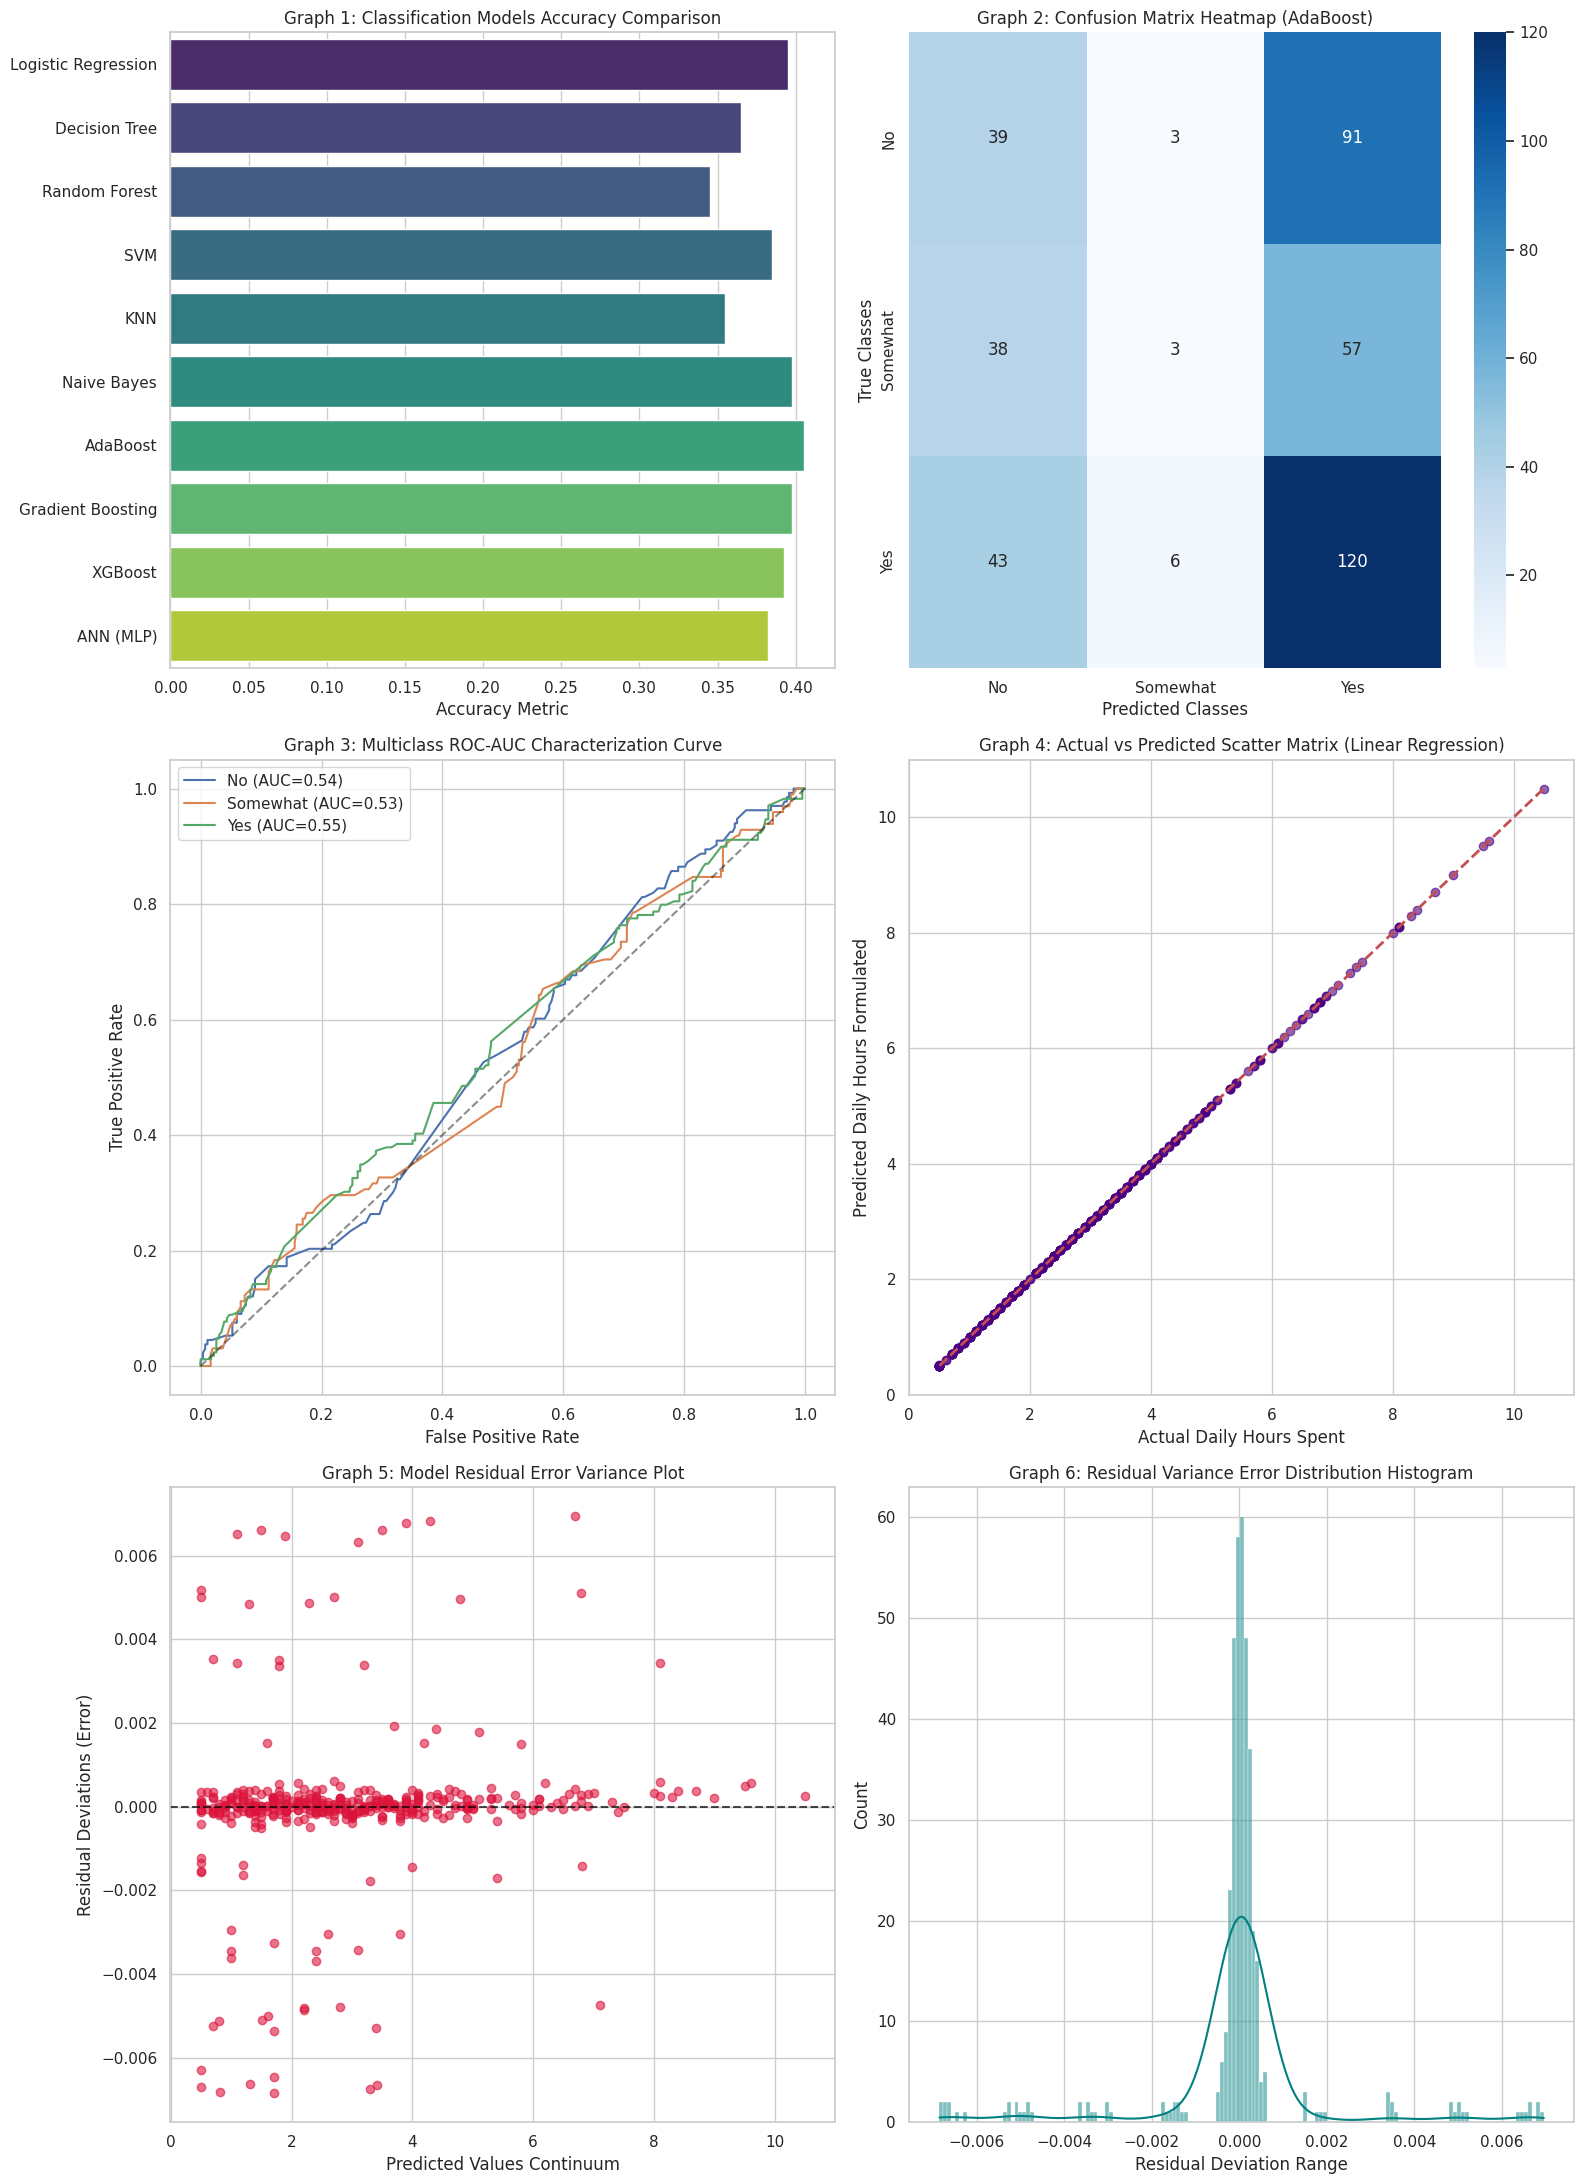

In [11]:
# Cell 7: Graphical Diagnostic Suite
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(16, 22))

# Graph 1: Classification Comparison Bar Chart
class_names = list(classification_scores.keys())
class_accs = [scores['Accuracy'] for scores in classification_scores.values()]
sns.barplot(x=class_accs, y=class_names, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Graph 1: Classification Models Accuracy Comparison')
axes[0,0].set_xlabel('Accuracy Metric')

# Graph 2: Confusion Matrix Heatmap
class_test_preds = best_class_model_obj.predict(X_test_c_scaled)
cm = confusion_matrix(y_test_c, class_test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_blueprint, yticklabels=class_labels_blueprint, ax=axes[0,1])
axes[0,1].set_title(f'Graph 2: Confusion Matrix Heatmap ({best_class_model_name})')
axes[0,1].set_xlabel('Predicted Classes')
axes[0,1].set_ylabel('True Classes')

# Graph 3: Classification AUC-ROC Multi-Curve
y_test_c_binarized = pd.get_dummies(y_test_c).values
if hasattr(best_class_model_obj, "predict_proba"):
    prob_scores = best_class_model_obj.predict_proba(X_test_c_scaled)
    for i, class_name in enumerate(class_labels_blueprint):
        fpr, tpr, _ = roc_curve(y_test_c_binarized[:, i], prob_scores[:, i])
        axes[1,0].plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc_score(y_test_c_binarized[:, i], prob_scores[:, i]):.2f})')
axes[1,0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1,0].set_title('Graph 3: Multiclass ROC-AUC Characterization Curve')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend()

# Graph 4: Regression Actual vs Predicted Values
reg_test_preds = best_reg_model_obj.predict(X_test_r_scaled)
axes[1,1].scatter(y_test_r, reg_test_preds, alpha=0.6, color='indigo')
axes[1,1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[1,1].set_title(f'Graph 4: Actual vs Predicted Scatter Matrix ({best_reg_model_name})')
axes[1,1].set_xlabel('Actual Daily Hours Spent')
axes[1,1].set_ylabel('Predicted Daily Hours Formulated')

# Graph 5: Residual Error Convergence Scatter Matrix
residuals = y_test_r - reg_test_preds
axes[2,0].scatter(reg_test_preds, residuals, alpha=0.6, color='crimson')
axes[2,0].axhline(y=0, color='black', linestyle='--', alpha=0.7)
axes[2,0].set_title('Graph 5: Model Residual Error Variance Plot')
axes[2,0].set_xlabel('Predicted Values Continuum')
axes[2,0].set_ylabel('Residual Deviations (Error)')

# Graph 6: Residual Distribution Symmetrical Skewness Density Histogram
sns.histplot(residuals, kde=True, color='teal', ax=axes[2,1])
axes[2,1].set_title('Graph 6: Residual Variance Error Distribution Histogram')
axes[2,1].set_xlabel('Residual Deviation Range')

plt.tight_layout()
plt.show()

In [14]:
# Cell 8: Packaging and Exporting Model Binaries (.pkl files)
from google.colab import files

# Package A: Classification Pipeline Pack
classification_export_pack = {
    'model': best_class_model_obj,
    'scaler': scaler_classification,
    'selected_features_blueprint': top_classification_features,
    'class_labels': class_labels_blueprint
}

with open('best_classification_behavior_model.pkl', 'wb') as f:
    pickle.dump(classification_export_pack, f)

# Package B: Regression Pipeline Pack
regression_export_pack = {
    'model': best_reg_model_obj,
    'scaler': scaler_regression,
    'selected_features_blueprint': top_regression_features
}

with open('best_regression_behavior_model.pkl', 'wb') as f:
    pickle.dump(regression_export_pack, f)

print(" [SUCCESS] Serialized binary .pkl configurations exported smoothly.")
print(" -> Downloading exported bundles directly to your system drive...")

# Triggers secure browser downloads
files.download('best_classification_behavior_model.pkl')
files.download('best_regression_behavior_model.pkl')

 [SUCCESS] Serialized binary .pkl configurations exported smoothly.
 -> Downloading exported bundles directly to your system drive...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>